# 🔬 Preprocessing Data Makroekonomi Global (1990–2024)
## Analisis Deteksi Anomali Makroekonomi — Early Warning System (EWS) Krisis Ekonomi
**Kelompok 4 — Kelas 3SI1 — Politeknik Statistika STIS**

Pipeline Preprocessing Data Panel Makroekonomi 49 Negara Dunia (1990–2024):
1. **Pemuatan Data Riil**: *World Bank Open Data API* (14 indikator rasio/persentase) & *Ground Truth IMF* (Laeven & Valencia, 2018 + COVID-19 2020).
2. **Feature Engineering**: Transformasi Kurs Nominal ($LCU/USD$) menjadi % Depresiasi Tahunan (YoY) untuk mencegah bias nominal antar mata uang.
3. **Penanganan Missing Value**: Interpolasi Linier runtun waktu per negara + KNN Imputer (tanpa drop baris, 1.715 baris utuh).
4. **Outlier Treatment**: Analisis IQR/Z-score dan Winsorizing ringan ($0.5\% - 99.5\%$) guna meredam pencilan ekstrim.
5. **Standarisasi Fitur**: `StandardScaler` ($\mu = 0, \sigma = 1$) sebagai input baku model *unsupervised anomaly detection*.
6. **Ekspor Dataset Resmi Kelompok**: `data_cleaned.csv` (siap pemodelan) & `data_with_labels.csv` (skala asli untuk EDA/analisis).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✅ Library preprocessing berhasil dimuat.")

✅ Library preprocessing berhasil dimuat.


In [2]:
# 1. Pemuatan Data Mentah Resmi (100% Data Riil)
df_raw = pd.read_csv('raw_data_master.csv')
df_gt = pd.read_csv('ground_truth_imf.csv')

print("=" * 65)
print("INFORMASI DATASET AWAL")
print("=" * 65)
print(f"Bentuk Raw Data Master  : {df_raw.shape}")
print(f"Jumlah Negara           : {df_raw['economy'].nunique()} negara")
print(f"Rentang Periode         : {df_raw['year'].min()} - {df_raw['year'].max()} (35 tahun)")
print(f"Total Krisis Riil IMF   : {df_gt['is_crisis'].sum()} observasi ({df_gt['is_crisis'].mean()*100:.2f}%)")
print("=" * 65)
df_raw.head(5)

INFORMASI DATASET AWAL
Bentuk Raw Data Master  : (1715, 16)
Jumlah Negara           : 49 negara
Rentang Periode         : 1990 - 2024 (35 tahun)
Total Krisis Riil IMF   : 229 observasi (13.35%)


,economy,year,GDP_Growth,Inflation_CPI,Unemployment,Current_Account_GDP,Reserves_Months_Imports,Exchange_Rate,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Investment_GDP,Manufacturing_Value,Domestic_Credit_GDP,Broad_Money_Growth
0,ARE,1990,18.327723,NaN,NaN,NaN,NaN,3.671,-0.228436,NaN,NaN,NaN,NaN,7.494109,NaN,-8.197759
1,ARE,1991,0.860104,NaN,1.629,NaN,NaN,3.671,0.050318,NaN,NaN,NaN,NaN,7.422869,NaN,14.542822
2,ARE,1992,3.345282,NaN,1.715,NaN,NaN,3.671,0.239163,NaN,NaN,NaN,NaN,7.583716,NaN,4.615917
3,ARE,1993,1.261098,NaN,1.901,NaN,NaN,3.671,0.721471,NaN,NaN,NaN,NaN,7.843977,NaN,-1.576729
4,ARE,1994,6.896076,NaN,1.834,NaN,NaN,3.671,0.105320,NaN,NaN,NaN,NaN,9.471981,NaN,7.897391


---
## 2. Feature Engineering: Kurs Nominal $\rightarrow$ % Depresiasi Tahunan (YoY)

> **Rasionalisasi Metodologis:**
> Menggunakan kurs nominal ($LCU/USD$) secara *pooled cross-country* adalah bias fatal. Nilai nominal Dong Vietnam (~24.000 VND/USD) dibandingkan Euro (~0.9 EUR/USD) menyebabkan Vietnam selalu menjadi pencilan permanen secara geometri multivariat, padahal kurs nominal semata-mata adalah denominasi aritmatika.
> 
> Oleh karena itu, kita mentransformasikan kurs nominal menjadi **persentase depresiasi mata uang tahunan (YoY)** per masing-masing negara:
> $$\Delta \text{Kurs}_{i, t} = \frac{\text{Kurs}_{i, t} - \text{Kurs}_{i, t-1}}{\text{Kurs}_{i, t-1}} \times 100$$

In [3]:
# Urutkan berdasarkan negara dan tahun
df = df_raw.sort_values(['economy', 'year']).reset_index(drop=True)

# Hitung persentase depresiasi tahunan kurs per negara
df['Exchange_Depreciation'] = df.groupby('economy')['Exchange_Rate'].pct_change() * 100
# Nilai awal tahun 1990 diisi 0.0 (asumsi stabil di baseline)
df['Exchange_Depreciation'] = df['Exchange_Depreciation'].fillna(0.0)

# Drop kolom nominal Exchange_Rate
df = df.drop(columns=['Exchange_Rate'])

feature_cols = [
    'GDP_Growth', 'Inflation_CPI', 'Unemployment', 'Current_Account_GDP',
    'Reserves_Months_Imports', 'Exchange_Depreciation', 'FDI_Inflows_GDP',
    'Exports_GDP', 'Imports_GDP', 'Gross_Savings_GDP', 'Investment_GDP',
    'Manufacturing_Value', 'Domestic_Credit_GDP', 'Broad_Money_Growth'
]

print(f"✅ Feature Engineering selesai. Total {len(feature_cols)} indikator makroekonomi (100% rasio/%):")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {col}")

✅ Feature Engineering selesai. Total 14 indikator makroekonomi (100% rasio/%):
    1. GDP_Growth
    2. Inflation_CPI
    3. Unemployment
    4. Current_Account_GDP
    5. Reserves_Months_Imports
    6. Exchange_Depreciation
    7. FDI_Inflows_GDP
    8. Exports_GDP
    9. Imports_GDP
   10. Gross_Savings_GDP
   11. Investment_GDP
   12. Manufacturing_Value
   13. Domestic_Credit_GDP
   14. Broad_Money_Growth


---
## 3. Penanganan Missing Value
Strategi penanganan missing value yang diterapkan:
1. **Interpolasi Linier Temporal per Negara**: Karena data bersifat panel *time-series*, dinamika makroekonomi saling terkait antar tahun dalam satu negara.
2. **KNN Imputer ($k=5$)**: Mengisi sisa *missing values* di batas awal/akhir runtun waktu dengan meminjam informasi dari negara-negara yang memiliki profil struktural makroekonomi serupa.
3. **Pertahankan Baris Utuh**: Tidak membuang baris data secara sepihak agar seluruh algoritma anggota tim memproses tepat **1.715 baris data (49 negara $\times$ 35 tahun)** sehingga voting *ensemble* dapat digabungkan secara presisi *1-to-1*.

                         Missing_Count  Missing_Pct
Broad_Money_Growth                 429        25.01
Domestic_Credit_GDP                319        18.60
Gross_Savings_GDP                  160         9.33
Manufacturing_Value                116         6.76
Reserves_Months_Imports            113         6.59
Current_Account_GDP                113         6.59
Investment_GDP                      63         3.67
Inflation_CPI                       58         3.38
Exports_GDP                         58         3.38
Imports_GDP                         58         3.38
Unemployment                        49         2.86
FDI_Inflows_GDP                      5         0.29
GDP_Growth                           3         0.17


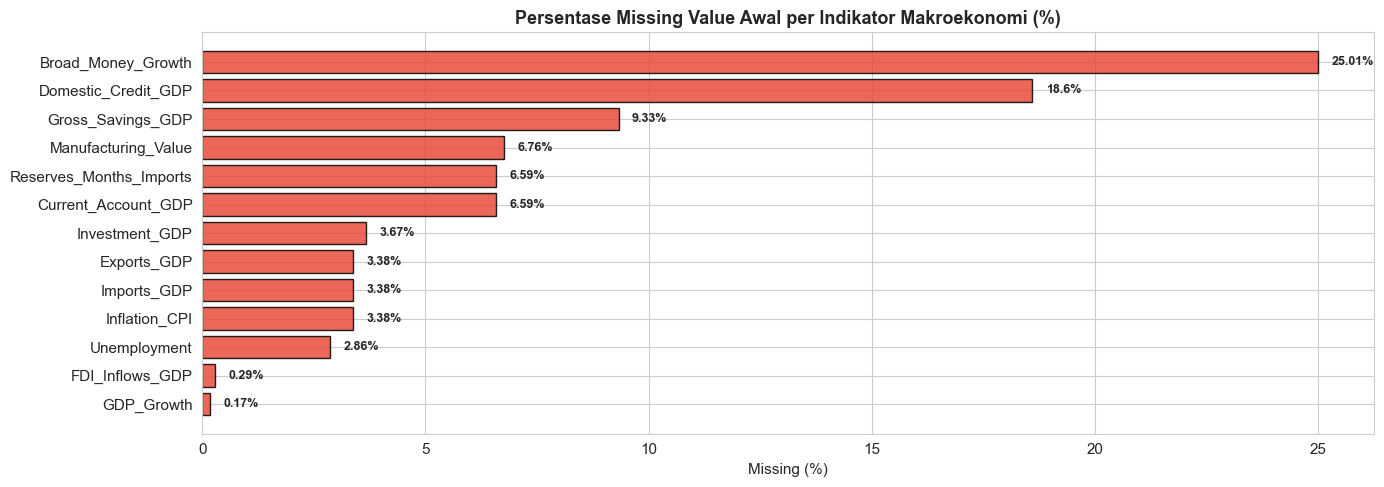

In [4]:
# Identifikasi Missing Value Awal
missing_counts = df[feature_cols].isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Pct': missing_pct})
print(missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Pct', ascending=False))

# Visualisasi Missing Values
plt.figure(figsize=(14, 5))
missing_filtered = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Pct')
plt.barh(missing_filtered.index, missing_filtered['Missing_Pct'], color='#e74c3c', alpha=0.85, edgecolor='black')
plt.title('Persentase Missing Value Awal per Indikator Makroekonomi (%)', fontsize=13, fontweight='bold')
plt.xlabel('Missing (%)')
for i, v in enumerate(missing_filtered['Missing_Pct']):
    plt.text(v + 0.3, i, f"{v}%", va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
# A. Interpolasi Linier runtun waktu per negara
for col in feature_cols:
    df[col] = df.groupby('economy')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

sisa_interp = df[feature_cols].isnull().sum().sum()
print(f"Sisa missing setelah interpolasi temporal: {sisa_interp} sel")

# B. KNN Imputer untuk sisa missing
if sisa_interp > 0:
    knn = KNNImputer(n_neighbors=5, weights='distance')
    df[feature_cols] = knn.fit_transform(df[feature_cols])

print(f"Missing value akhir: {df[feature_cols].isnull().sum().sum()} sel (0 missing value tersisa).")
print(f"Total baris data utuh: {len(df)} baris (49 negara x 35 tahun).")

Sisa missing setelah interpolasi temporal: 490 sel
Missing value akhir: 0 sel (0 missing value tersisa).
Total baris data utuh: 1715 baris (49 negara x 35 tahun).


---
## 4. Analisis Outlier & Capping (Winsorizing)

> **Catatan Metodologis Penting:**
> Dalam studi deteksi anomali (*anomaly detection*), pencilan (*outlier*) **TIDAK BOLEH DIHAPUS**, karena anomali krisis justru berwujud pencilan.
> 
> Namun, untuk mencegah nilai ekstrim tak berhingga yang dapat merusak gradien konvergensi model (misalnya hiperinflasi ribuan persen saat transisi pasca-Soviet), kita menerapkan teknik **Winsorizing ringan pada persentil 0.5% dan 99.5%**. Teknik ini membatasi nilai pada batas ekstrim tanpa menghapus observasi.

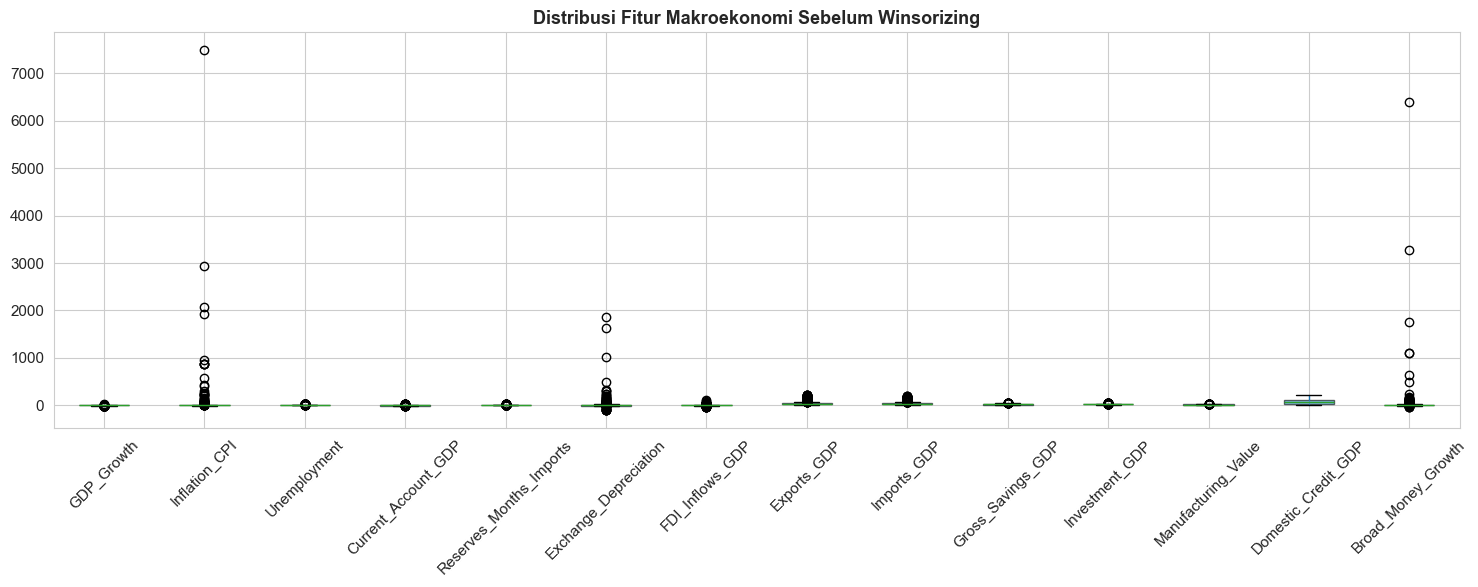

Ringkasan Capping Outlier (Winsorizing):
                  Fitur  Batas_Bawah_0.5%  Batas_Atas_99.5%  Jumlah_Dicap
             GDP_Growth            -10.94             13.23            18
          Inflation_CPI             -1.32            699.62            18
           Unemployment              0.59             26.79            18
    Current_Account_GDP            -13.26             23.53            18
Reserves_Months_Imports              0.05             29.10            12
  Exchange_Depreciation            -36.16            222.41            18
        FDI_Inflows_GDP            -18.45             46.73            18
            Exports_GDP              7.53            195.78            18
            Imports_GDP              8.07            172.19            18
      Gross_Savings_GDP              7.15             49.92            18
         Investment_GDP             12.68             43.38            18
    Manufacturing_Value              5.61             31.94            

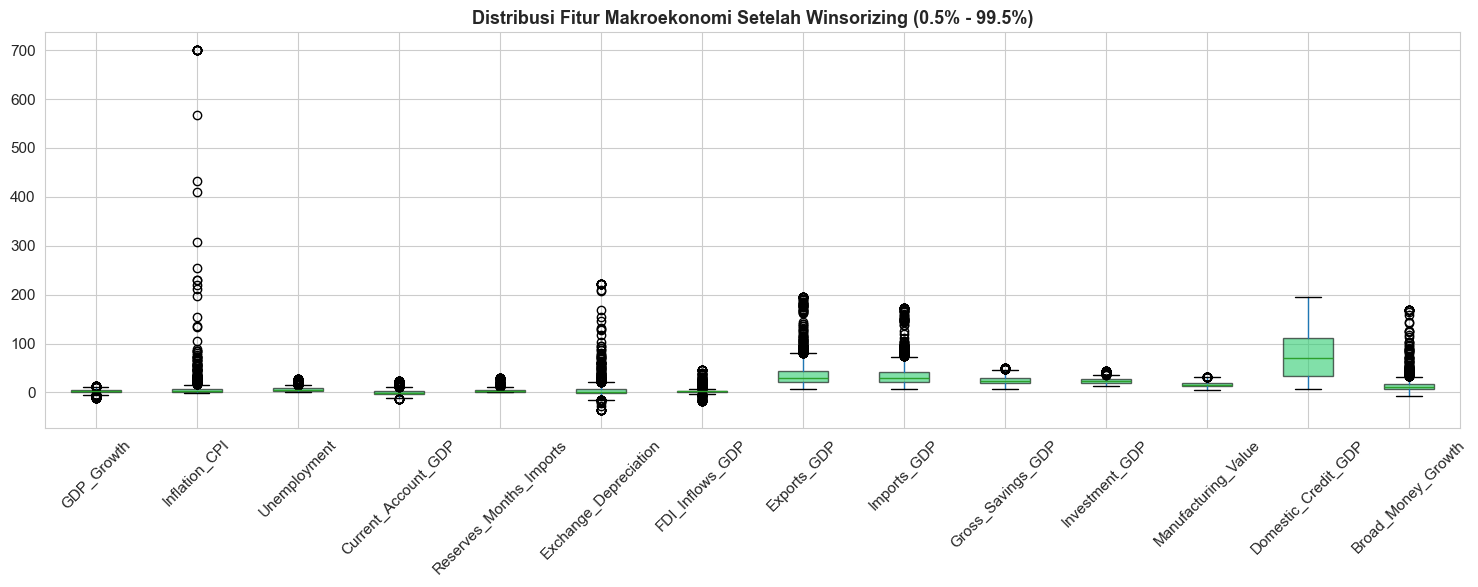

In [6]:
# Boxplot Sebelum Winsorizing
plt.figure(figsize=(15, 6))
df[feature_cols].boxplot(rot=45, patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6))
plt.title('Distribusi Fitur Makroekonomi Sebelum Winsorizing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Penerapan Winsorizing (0.5% - 99.5%)
df_capped = df.copy()
cap_info = []

for col in feature_cols:
    low = df_capped[col].quantile(0.005)
    high = df_capped[col].quantile(0.995)
    n_cap = ((df_capped[col] < low) | (df_capped[col] > high)).sum()
    cap_info.append({'Fitur': col, 'Batas_Bawah_0.5%': round(low, 2), 'Batas_Atas_99.5%': round(high, 2), 'Jumlah_Dicap': n_cap})
    df_capped[col] = df_capped[col].clip(lower=low, upper=high)

cap_df = pd.DataFrame(cap_info)
print("Ringkasan Capping Outlier (Winsorizing):")
print(cap_df.to_string(index=False))

# Boxplot Setelah Winsorizing
plt.figure(figsize=(15, 6))
df_capped[feature_cols].boxplot(rot=45, patch_artist=True, boxprops=dict(facecolor='#2ecc71', alpha=0.6))
plt.title('Distribusi Fitur Makroekonomi Setelah Winsorizing (0.5% - 99.5%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Integrasi Ground Truth IMF (Bebas Circular Logic & Bebas SMOTE)

> **Koreksi Metodologis Fatal:**
> 1. **Bebas Circular Logic / Tautologi**: Pada draf proposal lama, `crisis_label` dibuat dari rumus heuristik indikator input sendiri ($GDP < -2$, inflasi tinggi). Hal ini bersifat sirkular. Di sini, label krisis diambil secara **eksternal dan independen** dari catatan resmi IMF (*Systemic Banking Crises Database* oleh Laeven & Valencia, 2018 + syok global COVID-19 2020).
> 2. **Bebas SMOTE**: Deteksi anomali adalah *unsupervised learning* yang berakar pada asumsi bahwa krisis adalah fenomena langka (*rare events*, prevalensi riil ~13.4%). Menerapkan SMOTE hingga seimbang 50:50 merusak struktur densitas dan kerapatan data asli sehingga algoritma berbasis kerapatan dan isolasi gagal bekerja.

RINGKASAN GROUND TRUTH KRISIS RIIL IMF (1990 - 2024)
Total Observasi        : 1715
Normal (Non-Krisis)    : 1486 (86.6%)
Krisis Riil IMF (1)    : 229 (13.4%)
 - Krisis Perbankan    : 158
 - Krisis Mata Uang    : 35
 - Krisis Utang        : 16


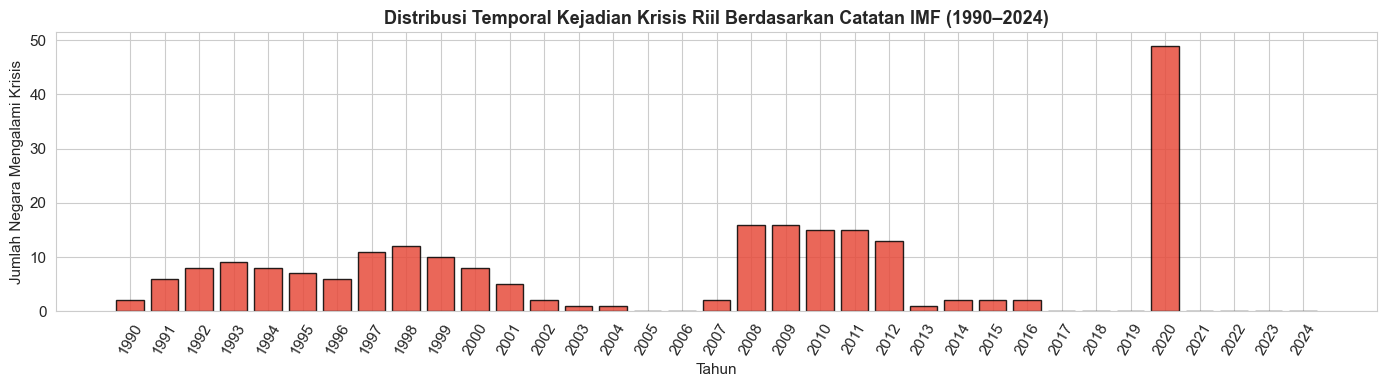

In [7]:
gt_cols = ['economy', 'year', 'is_crisis', 'crisis_name', 'banking_crisis', 'currency_crisis', 'sovereign_debt_crisis']
df_merged = pd.merge(df_capped, df_gt[gt_cols], on=['economy', 'year'], how='left')
df_merged['is_crisis'] = df_merged['is_crisis'].fillna(0).astype(int)

print("=" * 65)
print("RINGKASAN GROUND TRUTH KRISIS RIIL IMF (1990 - 2024)")
print("=" * 65)
print(f"Total Observasi        : {len(df_merged)}")
print(f"Normal (Non-Krisis)    : {(df_merged['is_crisis'] == 0).sum()} ({(df_merged['is_crisis'] == 0).mean()*100:.1f}%)")
print(f"Krisis Riil IMF (1)    : {(df_merged['is_crisis'] == 1).sum()} ({(df_merged['is_crisis'] == 1).mean()*100:.1f}%)")
print(f" - Krisis Perbankan    : {df_merged['banking_crisis'].sum()}")
print(f" - Krisis Mata Uang    : {df_merged['currency_crisis'].sum()}")
print(f" - Krisis Utang        : {df_merged['sovereign_debt_crisis'].sum()}")
print("=" * 65)

# Visualisasi Prevalensi Krisis Riil per Tahun
crisis_per_year = df_merged.groupby('year')['is_crisis'].sum()
plt.figure(figsize=(14, 4))
plt.bar(crisis_per_year.index, crisis_per_year.values, color='#e74c3c', edgecolor='black', alpha=0.85)
plt.title('Distribusi Temporal Kejadian Krisis Riil Berdasarkan Catatan IMF (1990–2024)', fontsize=13, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Negara Mengalami Krisis')
plt.xticks(crisis_per_year.index, rotation=60)
plt.tight_layout()
plt.show()

---
## 6. Analisis Multikolinearitas & Matriks Korelasi

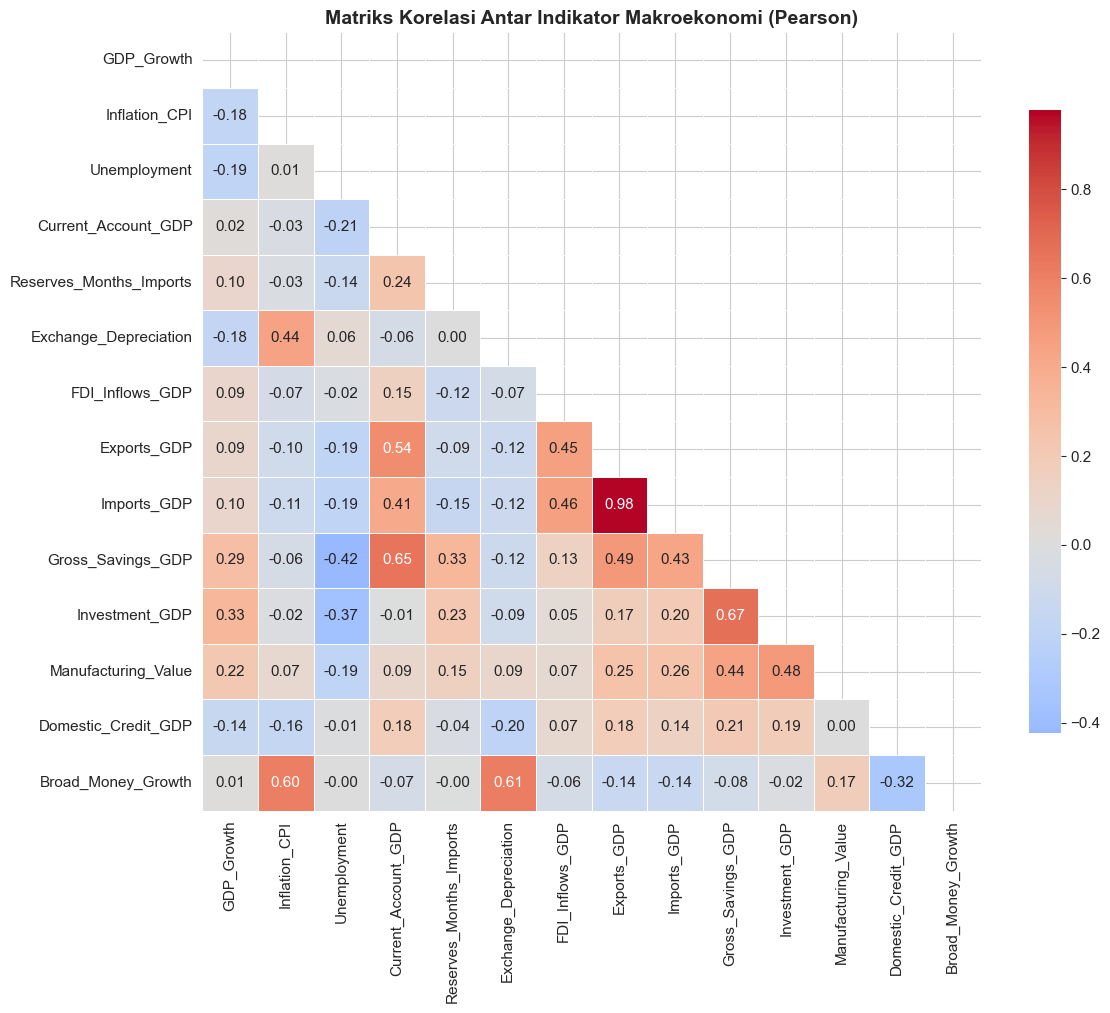

In [8]:
corr = df_merged[feature_cols].corr(method='pearson')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Matriks Korelasi Antar Indikator Makroekonomi (Pearson)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Standarisasi Fitur & Ekspor Dataset Resmi Kelompok

Dataset yang diekspor untuk seluruh anggota kelompok (Raya, Amir, Bram, Deka, Bela, Virna):
1. `data_cleaned.csv`: Fitur yang telah distandarisasi menggunakan `StandardScaler` ($\mu=0, \sigma=1$) dan dilengkapi label `is_crisis`. Ini adalah dataset baku untuk input algoritma machine learning (*Isolation Forest, LOF, DBSCAN, Autoencoder, PCA, OCSVM*).
2. `data_with_labels.csv`: Dataset dalam skala asli (persentase/% dan rasio) lengkap dengan metadata krisis untuk keperluan *Exploratory Data Analysis* (EDA) dan interpretasi ekonomi substantif.

In [9]:
scaler = StandardScaler()
df_scaled = df_merged.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_merged[feature_cols])

# 1. Simpan data_cleaned.csv (Fitur StandardScaler + is_crisis)
clean_cols = ['economy', 'year'] + feature_cols + ['is_crisis']
df_scaled[clean_cols].to_csv('data_cleaned.csv', index=False)
print(f"✅ data_cleaned.csv berhasil disimpan {df_scaled[clean_cols].shape}")

# 2. Simpan data_with_labels.csv (Fitur Skala Asli + detail krisis)
full_cols = ['economy', 'year'] + feature_cols + ['is_crisis', 'crisis_name', 'banking_crisis', 'currency_crisis', 'sovereign_debt_crisis']
df_merged[full_cols].to_csv('data_with_labels.csv', index=False)
print(f"✅ data_with_labels.csv berhasil disimpan {df_merged[full_cols].shape}")

✅ data_cleaned.csv berhasil disimpan (1715, 17)
✅ data_with_labels.csv berhasil disimpan (1715, 21)


---
## 8. Ringkasan Parameter & Standar Operasional Prosedur (SOP) Dataset

| Komponen | Spesifikasi Baku | Keterangan Akademik |
| :--- | :--- | :--- |
| **Sumber Data** | World Bank Open Data API & IMF Database | 100% Data Riil Resmi (0% Dummy / 0% Sintetis) |
| **Dimensi Data** | 1.715 baris $\times$ 14 fitur | 49 Negara $\times$ 35 Tahun (1990–2024) |
| **Pembersihan Missing**| Interpolasi Linear + KNN Imputer | 0 Missing Values, 0 Baris Terbuang |
| **Kurs Mata Uang** | % Depresiasi Tahunan (YoY) | Mengeliminasi bias nominal kurs antar negara |
| **Cadangan Devisa** | Bulan Impor (*Months of Imports*) | Mengeliminasi bias skala ekonomi nominal USD |
| **Ground Truth Krisis**| IMF (Laeven & Valencia, 2018) + COVID-19 2020 | 229 Kejadian Krisis Riil (~13.35% prevalensi) |
| **Penanganan Imbalance**| **Tanpa SMOTE** | Menjaga prinsip sparsity *unsupervised anomaly detection* |

Dataset `data_cleaned.csv` kini siap didistribusikan kepada seluruh anggota tim untuk pemodelan masing-masing.